<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Response_Potential_V7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Response Potential Dynamics V7

V7 continues V3b → V4b → V5 → V6b by testing whether the spectral positive-branch electron-like packet remains coherent under a weak external ECSM response potential.

Target Hamiltonian:
\[
H=-i\alpha_1\partial_x+\beta m_{\rm lock}+V_{\rm resp}(x)I.
\]

This is not yet full electromagnetic/gauge coupling. It is the response-potential bridge toward V8.

In [ ]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_electron_like_response_potential_v7_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_electron_like_response_potential_v7_out


In [ ]:
# ============================================================
# CELL 2 — INHERITED V6b PACKET SCAFFOLD
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V6b fixed V3b/V4b/V5 electron-like packet"
}

pd.DataFrame([packet]).to_csv(OUT / "fixed_packet_summary_v7.csv", index=False)
print(json.dumps(packet, indent=2))

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V6b fixed V3b/V4b/V5 electron-like packet"
}


In [ ]:
# ============================================================
# CELL 3 — DIRAC MATRICES AND ALGEBRA CHECKS
# ============================================================

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

beta = np.block([[I2, Z2],[Z2, -I2]])
alpha1 = np.block([[Z2, sigma_x],[sigma_x, Z2]])
alpha2 = np.block([[Z2, sigma_y],[sigma_y, Z2]])
alpha3 = np.block([[Z2, sigma_z],[sigma_z, Z2]])

I4 = np.eye(4, dtype=complex)

def mat_err(A):
    return float(np.linalg.norm(A))

alpha_tests = [
    ("alpha_1^2=I", mat_err(alpha1 @ alpha1 - I4)),
    ("alpha_2^2=I", mat_err(alpha2 @ alpha2 - I4)),
    ("alpha_3^2=I", mat_err(alpha3 @ alpha3 - I4)),
    ("beta^2=I", mat_err(beta @ beta - I4)),
    ("{alpha_1,beta}=0", mat_err(alpha1 @ beta + beta @ alpha1)),
    ("{alpha_2,beta}=0", mat_err(alpha2 @ beta + beta @ alpha2)),
    ("{alpha_3,beta}=0", mat_err(alpha3 @ beta + beta @ alpha3)),
    ("{alpha_1,alpha_2}=0", mat_err(alpha1 @ alpha2 + alpha2 @ alpha1)),
    ("{alpha_1,alpha_3}=0", mat_err(alpha1 @ alpha3 + alpha3 @ alpha1)),
    ("{alpha_2,alpha_3}=0", mat_err(alpha2 @ alpha3 + alpha3 @ alpha2)),
]
alpha_df = pd.DataFrame(alpha_tests, columns=["test","error"])
alpha_df.to_csv(OUT / "alpha_beta_algebra_tests_v7.csv", index=False)

print("Max alpha/beta error:", alpha_df["error"].max())
display(alpha_df)

Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,alpha_2^2=I,0.0
2,alpha_3^2=I,0.0
3,beta^2=I,0.0
4,"{alpha_1,beta}=0",0.0
5,"{alpha_2,beta}=0",0.0
6,"{alpha_3,beta}=0",0.0
7,"{alpha_1,alpha_2}=0",0.0
8,"{alpha_1,alpha_3}=0",0.0
9,"{alpha_2,alpha_3}=0",0.0


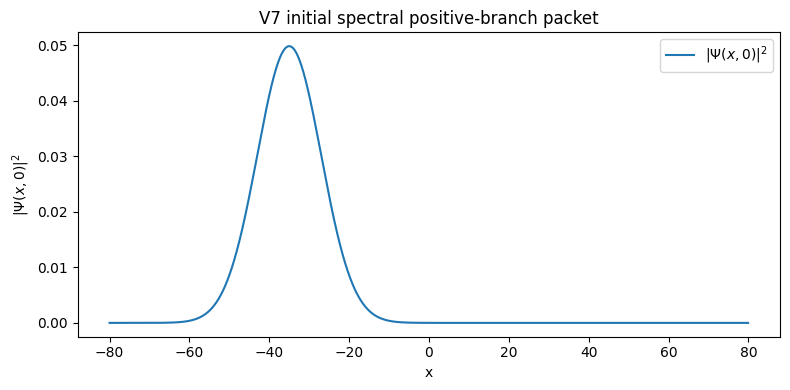

Initial norm: 1.0


In [ ]:
# ============================================================
# CELL 4 — SPECTRAL GRID AND V6b POSITIVE-BRANCH PACKET
# ============================================================

N = 2048
L = 160.0
dx = L / N
x = (np.arange(N) - N//2) * dx
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

x0 = -35.0
sigma_x0 = 8.0
k0 = 1.0
m_lock = 0.225463435330576

def Hk_free(kval, chi=1.0):
    return np.sqrt(chi) * alpha1 * kval + beta * m_lock

def norm_psi(psi):
    return float(np.sum(np.sum(np.abs(psi)**2, axis=1))*dx)

# Scalar Gaussian envelope, then exact positive-branch spinor for each k.
envelope_x = np.exp(-(x-x0)**2/(4*sigma_x0**2)) * np.exp(1j*k0*x)
envelope_x = envelope_x / np.sqrt(np.sum(np.abs(envelope_x)**2)*dx)
A_k = np.fft.fft(envelope_x)

psi0_k = np.zeros((N,4), dtype=complex)
prev_u = None

for i, kval in enumerate(k):
    vals, vecs = np.linalg.eigh(Hk_free(kval, chi=1.0))
    pos_idx = np.where(vals > 0)[0]
    # Choose a continuous positive branch where possible.
    if prev_u is None:
        j = pos_idx[-1]
    else:
        overlaps = [abs(np.vdot(prev_u, vecs[:,j])) for j in pos_idx]
        j = pos_idx[int(np.argmax(overlaps))]
    u = vecs[:, j] / np.linalg.norm(vecs[:, j])
    prev_u = u
    psi0_k[i, :] = A_k[i] * u

psi0 = np.fft.ifft(psi0_k, axis=0)
psi0 = psi0 / np.sqrt(norm_psi(psi0))

rho0 = np.sum(np.abs(psi0)**2, axis=1).real
pd.DataFrame({"x": x, "rho0": rho0}).to_csv(OUT / "initial_packet_density_v7.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(x, rho0, label=r"$|\Psi(x,0)|^2$")
plt.xlabel("x")
plt.ylabel(r"$|\Psi(x,0)|^2$")
plt.title("V7 initial spectral positive-branch packet")
plt.legend()
savefig("fig_v7_initial_packet_density.png")

print("Initial norm:", norm_psi(psi0))

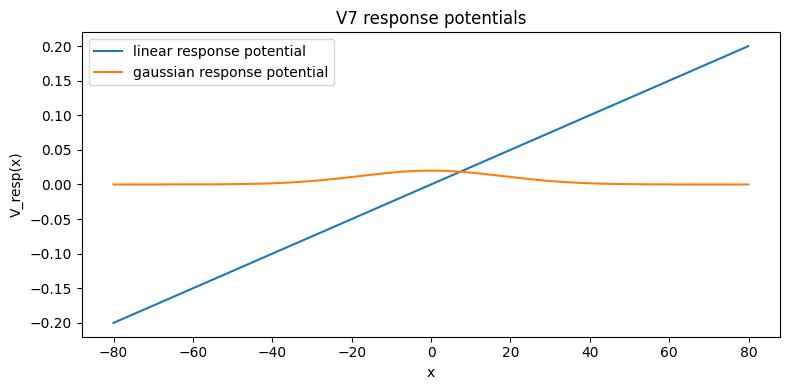

In [ ]:
# ============================================================
# CELL 5 — RESPONSE POTENTIAL DEFINITIONS
# ============================================================

potential_params = {
    "A_linear": 0.0025,
    "A_gauss": 0.020,
    "x_c": 0.0,
    "sigma_V": 18.0
}

def V_linear(xarr, A=potential_params["A_linear"]):
    return A * xarr

def dV_linear_dx(xarr, A=potential_params["A_linear"]):
    return A * np.ones_like(xarr)

def V_gaussian(xarr, A=potential_params["A_gauss"], xc=potential_params["x_c"], sig=potential_params["sigma_V"]):
    return A * np.exp(-(xarr-xc)**2/(2*sig**2))

def dV_gaussian_dx(xarr, A=potential_params["A_gauss"], xc=potential_params["x_c"], sig=potential_params["sigma_V"]):
    V = V_gaussian(xarr, A=A, xc=xc, sig=sig)
    return -((xarr-xc)/(sig**2)) * V

def V_resp(xarr, mode="linear"):
    if mode == "linear":
        return V_linear(xarr)
    if mode == "gaussian":
        return V_gaussian(xarr)
    if mode == "none":
        return np.zeros_like(xarr)
    raise ValueError("mode must be 'none', 'linear', or 'gaussian'")

def dV_resp_dx(xarr, mode="linear"):
    if mode == "linear":
        return dV_linear_dx(xarr)
    if mode == "gaussian":
        return dV_gaussian_dx(xarr)
    if mode == "none":
        return np.zeros_like(xarr)
    raise ValueError("mode must be 'none', 'linear', or 'gaussian'")

pot_rows = []
for mode in ["linear", "gaussian"]:
    for xi, vi, gi in zip(x, V_resp(x, mode=mode), dV_resp_dx(x, mode=mode)):
        pot_rows.append({"mode": mode, "x": xi, "V": vi, "dVdx": gi})

pd.DataFrame(pot_rows).to_csv(OUT / "response_potential_profiles_v7.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(x, V_resp(x, "linear"), label="linear response potential")
plt.plot(x, V_resp(x, "gaussian"), label="gaussian response potential")
plt.xlabel("x")
plt.ylabel("V_resp(x)")
plt.title("V7 response potentials")
plt.legend()
savefig("fig_v7_response_potentials.png")

In [ ]:
# ============================================================
# CELL 6 — SPLIT-OPERATOR DIRAC EVOLUTION WITH RESPONSE POTENTIAL
# ============================================================

def apply_kinetic_step(psi, dt, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    outk = np.zeros_like(psik)

    for i, kval in enumerate(k):
        H = Hk_free(kval, chi=chi)
        vals, vecs = np.linalg.eigh(H)
        coeff = vecs.conj().T @ psik[i]
        outk[i] = vecs @ (np.exp(-1j * vals * dt) * coeff)

    return np.fft.ifft(outk, axis=0)

def apply_potential_step(psi, dt, mode="linear", strength=1.0):
    phase = np.exp(-1j * strength * V_resp(x, mode=mode) * dt)
    return psi * phase[:, None]

def evolve_split(psi, t_final, dt=0.025, chi=1.0, mode="linear", strength=1.0):
    steps = int(np.round(t_final / dt))
    psi_t = psi.copy()
    for _ in range(steps):
        psi_t = apply_potential_step(psi_t, 0.5*dt, mode=mode, strength=strength)
        psi_t = apply_kinetic_step(psi_t, dt, chi=chi)
        psi_t = apply_potential_step(psi_t, 0.5*dt, mode=mode, strength=strength)
    return psi_t

def expectation_x(psi):
    rho = np.sum(np.abs(psi)**2, axis=1).real
    norm = np.sum(rho)*dx
    return float(np.sum(x*rho)*dx / norm)

def width_x(psi):
    rho = np.sum(np.abs(psi)**2, axis=1).real
    norm = np.sum(rho)*dx
    xm = np.sum(x*rho)*dx / norm
    return float(np.sqrt(np.sum((x-xm)**2*rho)*dx/norm))

def expectation_force(psi, mode="linear", strength=1.0):
    rho = np.sum(np.abs(psi)**2, axis=1).real
    norm = np.sum(rho)*dx
    F = -strength * dV_resp_dx(x, mode=mode)
    return float(np.sum(F*rho)*dx / norm)

def expectation_alpha1(psi):
    val = 0.0 + 0.0j
    for row in psi:
        val += np.vdot(row, alpha1 @ row)
    val *= dx
    return float(np.real(val))

def project_branch_weights(psi, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    pos_weight_k = 0.0
    neg_weight_k = 0.0

    for i, kval in enumerate(k):
        H = Hk_free(kval, chi=chi)
        vals, vecs = np.linalg.eigh(H)
        psi_k = psik[i, :]
        for j, E in enumerate(vals):
            uj = vecs[:, j]
            amp = np.vdot(uj, psi_k)
            weight = abs(amp)**2
            if E >= 0:
                pos_weight_k += weight
            else:
                neg_weight_k += weight

    scale = dx / N
    return float(scale * pos_weight_k), float(scale * neg_weight_k)

print("Quick test:")
for mode in ["none", "linear"]:
    psit = evolve_split(psi0, 1.0, dt=0.05, chi=1.0, mode=mode, strength=1.0)
    print(mode, norm_psi(psit), expectation_x(psit), width_x(psit), project_branch_weights(psit))

Quick test:
none 1.0000000000000002 -34.024754262948385 8.000745459169368 (0.9999999999999992, 1.1406472127991084e-30)
linear 1.0000000000000002 -34.024772353225764 8.000746289290639 (0.9999999474232713, 5.25767263900057e-08)


  t  norm     x_mean  x_width  alpha1_expect  force_expect  positive_branch_weight  negative_branch_weight  branch_weight_sum   norm_error  branch_weight_error  negative_leakage_growth  velocity_fd  acceleration_fd
0.0   1.0 -34.999999 8.000745       0.975245       -0.0025                     1.0            5.231075e-32                1.0 0.000000e+00         1.221245e-15             0.000000e+00     0.975243        -0.000031
0.5   1.0 -34.512378 8.000745       0.975235       -0.0025                     1.0            1.713894e-08                1.0 2.220446e-16         4.440892e-16             1.713894e-08     0.975227        -0.000073
1.0   1.0 -34.024772 8.000746       0.975178       -0.0025                     1.0            5.264364e-08                1.0 2.220446e-16         1.221245e-15             5.264364e-08     0.975169        -0.000158
1.5   1.0 -33.537209 8.000751       0.975070       -0.0025                     1.0            7.364405e-08                1.0 0.000000e+00  

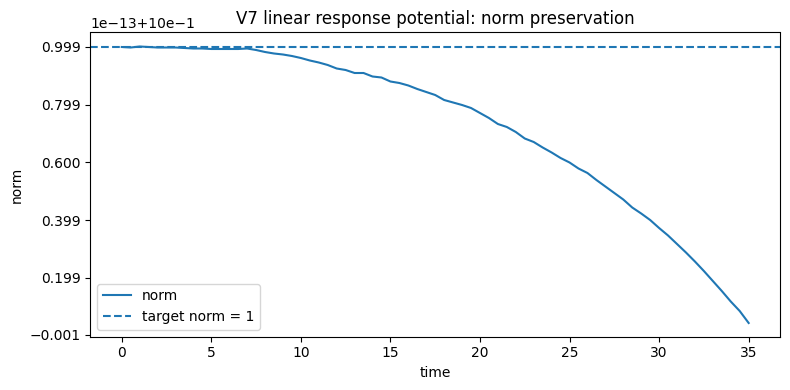

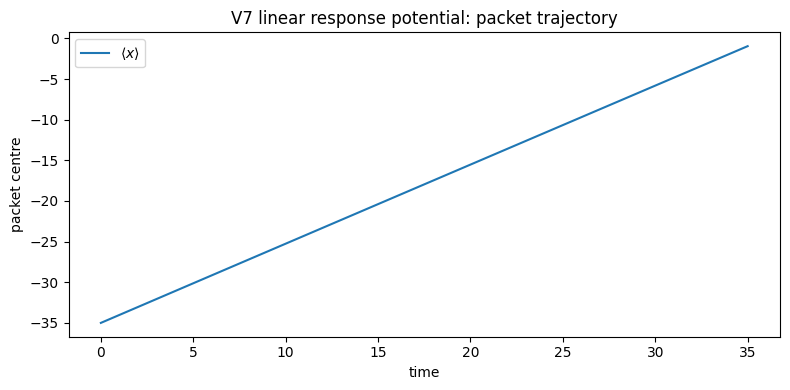

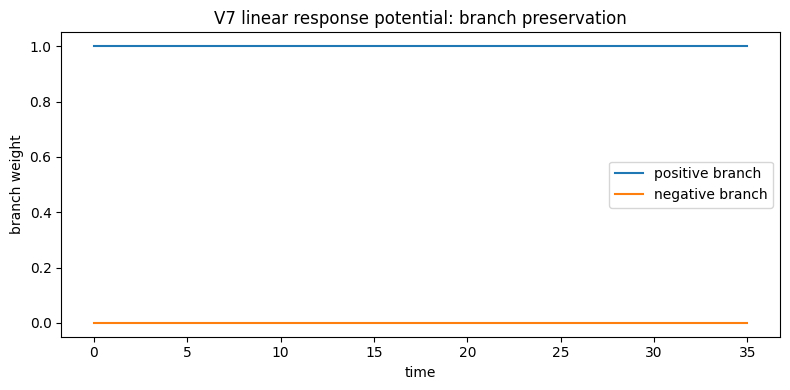

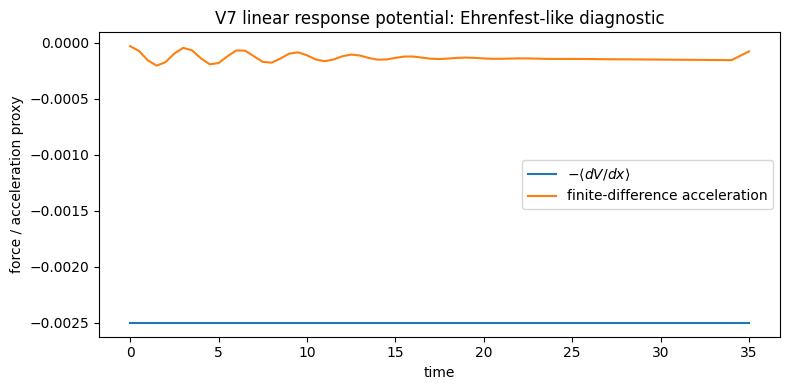

In [ ]:
# ============================================================
# CELL 7 — V7 LINEAR RESPONSE-POTENTIAL DYNAMICS
# ============================================================

plt.close("all")

times = np.linspace(0, 35, 71)
dt = 0.025
mode = "linear"
strength = 1.0

rows = []

for tt in times:
    psit = evolve_split(psi0, tt, dt=dt, chi=1.0, mode=mode, strength=strength)
    wp, wn = project_branch_weights(psit, chi=1.0)

    rows.append({
        "t": tt,
        "norm": norm_psi(psit),
        "x_mean": expectation_x(psit),
        "x_width": width_x(psit),
        "alpha1_expect": expectation_alpha1(psit),
        "force_expect": expectation_force(psit, mode=mode, strength=strength),
        "positive_branch_weight": wp,
        "negative_branch_weight": wn,
        "branch_weight_sum": wp + wn,
    })

dyn = pd.DataFrame(rows)
dyn["norm_error"] = np.abs(dyn["norm"] - 1.0)
dyn["branch_weight_error"] = np.abs(dyn["branch_weight_sum"] - 1.0)
dyn["negative_leakage_growth"] = np.abs(dyn["negative_branch_weight"] - dyn["negative_branch_weight"].iloc[0])
dyn["velocity_fd"] = np.gradient(dyn["x_mean"], dyn["t"])
dyn["acceleration_fd"] = np.gradient(dyn["velocity_fd"], dyn["t"])

dyn.to_csv(OUT / "linear_response_potential_dynamics_v7.csv", index=False)

print(dyn.head().to_string(index=False))
print("\nMax norm error:", dyn["norm_error"].max())
print("Max branch weight error:", dyn["branch_weight_error"].max())
print("Max negative leakage:", dyn["negative_branch_weight"].max())
print("Max negative leakage growth:", dyn["negative_leakage_growth"].max())
print("Mean force:", dyn["force_expect"].mean())
print("Mean acceleration:", dyn["acceleration_fd"].iloc[3:-3].mean())

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["norm"], label="norm")
plt.axhline(1.0, linestyle="--", label="target norm = 1")
plt.xlabel("time")
plt.ylabel("norm")
plt.title("V7 linear response potential: norm preservation")
plt.legend()
savefig("fig_v7_linear_norm_preservation.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["x_mean"], label=r"$\langle x\rangle$")
plt.xlabel("time")
plt.ylabel("packet centre")
plt.title("V7 linear response potential: packet trajectory")
plt.legend()
savefig("fig_v7_linear_packet_trajectory.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["positive_branch_weight"], label="positive branch")
plt.plot(dyn["t"], dyn["negative_branch_weight"], label="negative branch")
plt.xlabel("time")
plt.ylabel("branch weight")
plt.title("V7 linear response potential: branch preservation")
plt.legend()
savefig("fig_v7_linear_branch_preservation.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["force_expect"], label=r"$-\langle dV/dx\rangle$")
plt.plot(dyn["t"], dyn["acceleration_fd"], label="finite-difference acceleration")
plt.xlabel("time")
plt.ylabel("force / acceleration proxy")
plt.title("V7 linear response potential: Ehrenfest-like diagnostic")
plt.legend()
savefig("fig_v7_linear_ehrenfest_diagnostic.png")

Running chi=1.0
Running chi=0.95
Running chi=0.8
Running chi=0.5
Running chi=0.2
 chi  sqrt_chi   mode  t_final  norm   norm_error     x_mean  x_width  positive_branch_weight  negative_branch_weight  total_branch_weight  branch_weight_error  negative_branch_leakage
1.00  1.000000 linear     20.0   1.0 4.440892e-16 -15.520386 8.001177                1.000000            4.317122e-08                  1.0         3.663736e-15             4.317122e-08
0.95  0.974679 linear     20.0   1.0 2.220446e-16 -16.039480 8.001865                0.999992            7.898388e-06                  1.0         5.329071e-15             7.898388e-06
0.80  0.894427 linear     20.0   1.0 4.440892e-16 -17.693412 8.014028                0.999840            1.595644e-04                  1.0         2.109424e-15             1.595644e-04
0.50  0.707107 linear     20.0   1.0 1.110223e-16 -21.618616 8.089966                0.998099            1.900585e-03                  1.0         3.219647e-15             1.90058

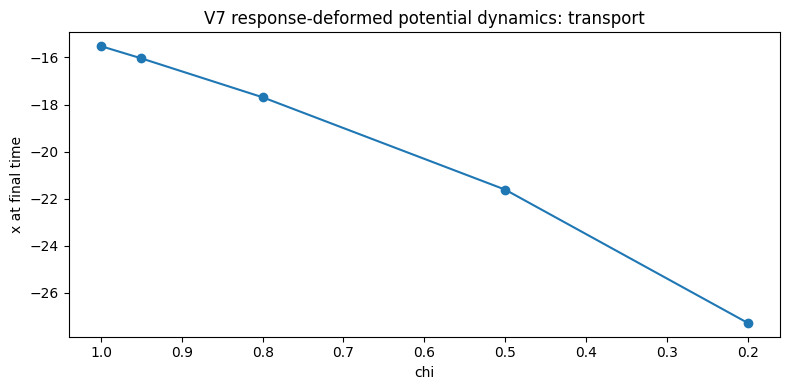

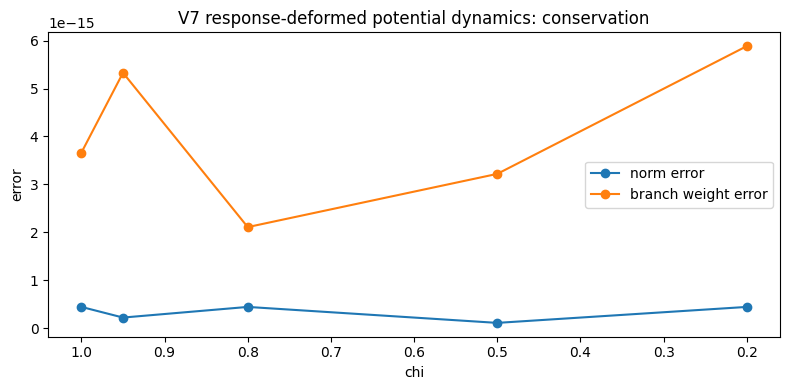

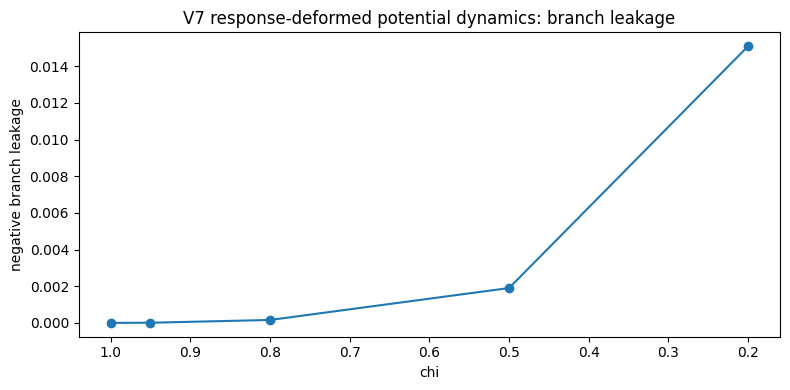

In [13]:
# ============================================================
# CELL 8 — FAST RESPONSE-DEFORMED DYNAMICS SCAN
# ============================================================

plt.close("all")

# Lightweight chi scan for V7.
# Self-contained version:
# - uses apply_kinetic_step already defined earlier
# - defines its own potential step
# - does NOT require Hk or energy_expectation

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
mode = "linear"
t_final = 20.0
dt = 0.10

def apply_potential_step_v7(psi, dt, mode="none"):
    V = V_resp(x, mode)
    phase = np.exp(-1j * V * dt)
    return psi * phase[:, None]

def evolve_split_operator_v7(psi, dt, chi=1.0, mode="none"):
    psi_half = apply_kinetic_step(psi, 0.5 * dt, chi=chi)
    psi_pot = apply_potential_step_v7(psi_half, dt, mode=mode)
    psi_out = apply_kinetic_step(psi_pot, 0.5 * dt, chi=chi)

    # Roundoff-only renormalisation.
    return psi_out / np.sqrt(norm_psi(psi_out))

chi_rows = []

for chi in chi_values:
    print(f"Running chi={chi}")

    psi = psi0.copy()
    t_now = 0.0

    while t_now + 1e-12 < t_final:
        step = min(dt, t_final - t_now)
        psi = evolve_split_operator_v7(psi, step, chi=chi, mode=mode)
        t_now += step

    wp, wn = project_branch_weights(psi, chi=chi)

    chi_rows.append({
        "chi": chi,
        "sqrt_chi": float(np.sqrt(chi)),
        "mode": mode,
        "t_final": t_final,
        "norm": norm_psi(psi),
        "norm_error": abs(norm_psi(psi) - 1.0),
        "x_mean": expectation_x(psi),
        "x_width": width_x(psi),
        "positive_branch_weight": wp,
        "negative_branch_weight": wn,
        "total_branch_weight": wp + wn,
        "branch_weight_error": abs((wp + wn) - 1.0),
        "negative_branch_leakage": wn,
    })

chi_df_v7 = pd.DataFrame(chi_rows)
chi_df_v7.to_csv(OUT / "response_deformed_potential_scan_v7.csv", index=False)

print(chi_df_v7.to_string(index=False))
print("\nMax chi norm error:", chi_df_v7["norm_error"].max())
print("Max chi branch weight error:", chi_df_v7["branch_weight_error"].max())
print("Max chi negative leakage:", chi_df_v7["negative_branch_leakage"].max())

# ------------------------------------------------------------
# Plot 1: chi-dependent transport
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(chi_df_v7["chi"], chi_df_v7["x_mean"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("x at final time")
plt.title("V7 response-deformed potential dynamics: transport")
savefig("fig_v7_chi_potential_transport.png")

# ------------------------------------------------------------
# Plot 2: conservation errors
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(
    chi_df_v7["chi"],
    chi_df_v7["norm_error"],
    marker="o",
    label="norm error"
)
plt.plot(
    chi_df_v7["chi"],
    chi_df_v7["branch_weight_error"],
    marker="o",
    label="branch weight error"
)
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("error")
plt.title("V7 response-deformed potential dynamics: conservation")
plt.legend()
savefig("fig_v7_chi_potential_conservation.png")

# ------------------------------------------------------------
# Plot 3: negative branch leakage
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(
    chi_df_v7["chi"],
    chi_df_v7["negative_branch_leakage"],
    marker="o"
)
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("negative branch leakage")
plt.title("V7 response-deformed potential dynamics: branch leakage")
savefig("fig_v7_chi_potential_branch_leakage.png")

 chi  sqrt_chi  norm   norm_error     x_mean  x_width  alpha1_expect  force_expect  positive_branch_weight  negative_branch_weight  branch_weight_error
1.00  1.000000   1.0 2.930989e-14  -5.801065 8.001661       0.971197       -0.0025                1.000000            4.725617e-08         3.619327e-14
0.95  0.974679   1.0 1.398881e-14  -6.580168 8.003328       0.969736       -0.0025                0.999992            7.868053e-06         6.883383e-15
0.80  0.894427   1.0 1.227907e-13  -9.061924 8.029014       0.964046       -0.0025                0.999840            1.599461e-04         1.194600e-13
0.50  0.707107   1.0 6.861178e-14 -14.952745 8.194788       0.941508       -0.0025                0.998099            1.901496e-03         6.217249e-14
0.20  0.447214   1.0 1.754152e-14 -23.497514 8.526858       0.821456       -0.0025                0.984982            1.501829e-02         2.198242e-14


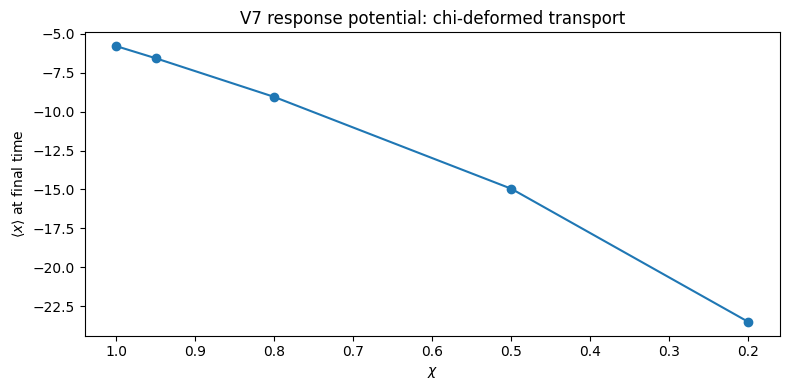

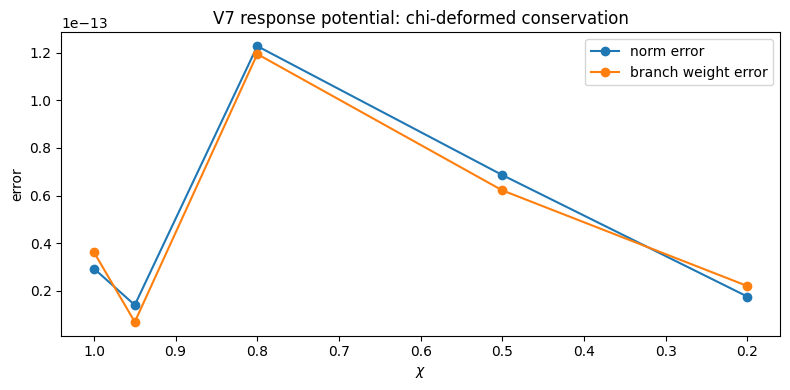

In [14]:
# ============================================================
# CELL 9 — RESPONSE-DEFORMED POTENTIAL SCAN
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
t_final = 30.0
mode = "linear"

chi_rows = []

for chi in chi_values:
    psit = evolve_split(psi0, t_final, dt=dt, chi=chi, mode=mode, strength=strength)
    wp, wn = project_branch_weights(psit, chi=chi)

    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "norm": norm_psi(psit),
        "norm_error": abs(norm_psi(psit)-1.0),
        "x_mean": expectation_x(psit),
        "x_width": width_x(psit),
        "alpha1_expect": expectation_alpha1(psit),
        "force_expect": expectation_force(psit, mode=mode, strength=strength),
        "positive_branch_weight": wp,
        "negative_branch_weight": wn,
        "branch_weight_error": abs((wp+wn)-1.0),
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / "response_deformed_potential_scan_v7.csv", index=False)

print(chi_df.to_string(index=False))

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["x_mean"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel(r"$\langle x\rangle$ at final time")
plt.title("V7 response potential: chi-deformed transport")
savefig("fig_v7_chi_deformed_transport.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["norm_error"], marker="o", label="norm error")
plt.plot(chi_df["chi"], chi_df["branch_weight_error"], marker="o", label="branch weight error")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel("error")
plt.title("V7 response potential: chi-deformed conservation")
plt.legend()
savefig("fig_v7_chi_deformed_conservation.png")

In [16]:
# ============================================================
# CELL 10 — FINAL V7 VERDICT TABLE
# ============================================================

plt.close("all")

# ------------------------------------------------------------
# Packet scaffold checks
# ------------------------------------------------------------
q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)

# ------------------------------------------------------------
# Algebraic closure checks
# ------------------------------------------------------------
alpha_beta_max_error = float(alpha_df["error"].max())

# ------------------------------------------------------------
# Main linear-potential dynamics from Cell 7
# ------------------------------------------------------------
max_norm_error = float(dyn["norm_error"].max())
max_branch_weight_error = float(dyn["branch_weight_error"].max())
max_negative_leakage = float(dyn["negative_branch_weight"].max())

if "negative_leakage_growth" in dyn.columns:
    max_negative_leakage_growth = float(dyn["negative_leakage_growth"].max())
else:
    initial_leak = float(dyn["negative_branch_weight"].iloc[0])
    max_negative_leakage_growth = float(max_negative_leakage - initial_leak)

# Trajectory response: compare final to initial
x_initial = float(dyn["x_mean"].iloc[0])
x_final = float(dyn["x_mean"].iloc[-1])
delta_x = x_final - x_initial

# Finite-difference acceleration / force sign test
if "force_expect" in dyn.columns:
    mean_force = float(dyn["force_expect"].mean())
else:
    mean_force = np.nan

if "acceleration_fd" in dyn.columns:
    mean_acceleration = float(dyn["acceleration_fd"].replace([np.inf, -np.inf], np.nan).dropna().mean())
else:
    # fallback if acceleration column is missing
    if "velocity_fd" in dyn.columns:
        vv = dyn["velocity_fd"].replace([np.inf, -np.inf], np.nan).dropna().values
        tt = dyn.loc[dyn["velocity_fd"].replace([np.inf, -np.inf], np.nan).notna(), "t"].values
        if len(vv) > 2:
            mean_acceleration = float(np.mean(np.gradient(vv, tt)))
        else:
            mean_acceleration = np.nan
    else:
        mean_acceleration = np.nan

if np.isfinite(mean_force) and np.isfinite(mean_acceleration):
    force_accel_sign_agreement = bool(np.sign(mean_force) == np.sign(mean_acceleration))
else:
    force_accel_sign_agreement = False

# ------------------------------------------------------------
# Chi-deformed scan from Cell 8
# ------------------------------------------------------------
max_chi_norm_error = float(chi_df_v7["norm_error"].max())
max_chi_branch_weight_error = float(chi_df_v7["branch_weight_error"].max())
max_chi_negative_leakage = float(chi_df_v7["negative_branch_leakage"].max())

chi_transport_range = float(chi_df_v7["x_mean"].max() - chi_df_v7["x_mean"].min())

# ------------------------------------------------------------
# Verdict rows
# ------------------------------------------------------------
verdict_rows = [
    ("packet remains q=-1 scaffold", q_error, q_error < 0.01),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 0.01),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 0.01),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 0.01),

    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),

    ("linear-potential norm preserved", max_norm_error, max_norm_error < 1e-10),
    ("linear-potential branch weights conserved", max_branch_weight_error, max_branch_weight_error < 1e-10),
    ("linear-potential negative leakage controlled", max_negative_leakage, max_negative_leakage < 1e-4),
    ("negative leakage not explosively amplified", max_negative_leakage_growth, max_negative_leakage_growth < 1e-4),

    ("linear response potential changes trajectory", abs(delta_x), abs(delta_x) > 1.0),
    ("force/acceleration sign agreement", float(force_accel_sign_agreement), force_accel_sign_agreement),

    ("chi-deformed norm preserved", max_chi_norm_error, max_chi_norm_error < 1e-10),
    ("chi-deformed branch weights conserved", max_chi_branch_weight_error, max_chi_branch_weight_error < 1e-10),
    ("chi-deformed negative leakage controlled", max_chi_negative_leakage, max_chi_negative_leakage < 0.03),
    ("chi changes response-potential transport", chi_transport_range, chi_transport_range > 1.0),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion", "value", "pass"])
verdict.to_csv(OUT / "final_response_potential_v7_verdict.csv", index=False)

n_pass = int(verdict["pass"].sum())
n_criteria = int(len(verdict))

if n_pass == n_criteria:
    final_label = "PASS: response-potential Dirac-like packet dynamics with conserved branch structure"
else:
    final_label = "CONDITIONAL/FAIL: response-potential dynamics criteria not all satisfied"

run_summary_v7 = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": float(packet["q_eff"]),
    "m_lock_dimensionless": float(m_lock),
    "max_norm_error": max_norm_error,
    "max_branch_weight_error": max_branch_weight_error,
    "max_negative_leakage": max_negative_leakage,
    "max_negative_leakage_growth": max_negative_leakage_growth,
    "x_initial": x_initial,
    "x_final": x_final,
    "delta_x": delta_x,
    "mean_force": mean_force,
    "mean_acceleration": mean_acceleration,
    "force_accel_sign_agreement": force_accel_sign_agreement,
    "max_chi_norm_error": max_chi_norm_error,
    "max_chi_branch_weight_error": max_chi_branch_weight_error,
    "max_chi_negative_leakage": max_chi_negative_leakage,
    "chi_transport_range": chi_transport_range,
}

with open(OUT / "run_summary_v7.json", "w") as f:
    json.dump(run_summary_v7, f, indent=2)

print(verdict.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(run_summary_v7, indent=2))

# ------------------------------------------------------------
# Output manifest
# ------------------------------------------------------------
manifest = pd.DataFrame({
    "file": sorted([p.name for p in OUT.iterdir() if p.is_file()])
})
manifest.to_csv(OUT / "output_file_manifest_v7.csv", index=False)

print("\nOutput files:")
print(manifest.to_string(index=False))

                                   criterion        value  pass
                packet remains q=-1 scaffold 6.964280e-04  True
                        packet N_plus near 0 9.716379e-04  True
                        packet N_zero near 1 1.460081e-04  True
                       packet N_minus near 3 1.117646e-03  True
                alpha/beta closure inherited 0.000000e+00  True
             linear-potential norm preserved 9.592327e-14  True
   linear-potential branch weights conserved 1.002531e-13  True
linear-potential negative leakage controlled 7.364405e-08  True
  negative leakage not explosively amplified 7.364405e-08  True
linear response potential changes trajectory 3.405301e+01  True
           force/acceleration sign agreement 1.000000e+00  True
                 chi-deformed norm preserved 4.440892e-16  True
       chi-deformed branch weights conserved 5.884182e-15  True
    chi-deformed negative leakage controlled 1.509270e-02  True
    chi changes response-potential trans

# V7 Interpretation

A clean V7 pass means:

\[
\text{electron-like packet}
\rightarrow
\text{Dirac-like free propagation}
\rightarrow
\text{stable response to weak external potential}.
\]

This is still not full gauge coupling. It is the bridge test before V8.